In [1]:
# Running locally instead of Colab — no drive mount needed


Mounted at /content/drive


In [2]:
path_1 = "../data/QVI_transaction_data.csv"
path_2 = "../data/QVI_purchase_behaviour.csv"


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
transaction_data = pd.read_csv(path_1)
purchase_behaviour = pd.read_csv(path_2)

In [5]:
df_1 = transaction_data.copy()
df_2 = purchase_behaviour.copy()

In [ ]:
df_1.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [6]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


There are no null values so it's well and good. Here you can see date is in **INT** Type; so we should change it into **DATE** type

In [7]:
df_1['DATE'] = pd.to_datetime(df_1['DATE'], origin='1899-12-30', unit='D')

In [ ]:
df_1.info()

In [ ]:
df_1.head()

In [8]:
all_words = df_1['PROD_NAME'].str.lower().str.replace(r'\b\d+g\b|\b\d+ml\b', '', regex=True).str.findall(r'\b\w+\b').explode()
word_counts = all_words.value_counts().sort_values(ascending=False)
word_counts = word_counts.reset_index()
word_counts.columns = ['word', 'count']
display(word_counts)

,word,count
0,chips,49770
1,kettle,41288
2,smiths,28860
3,salt,27976
4,cheese,27890
...,...,...
196,sunbites,1432
197,pc,1431
198,ncc,1419
199,garden,1419


This shows the words and their frequencies in descending order, here we can see that these words are describing chips, but there are some words which aren't chips like salsa. So next we are gonna remove data which contains salsa in the product description

In [9]:
df_1 = df_1[~df_1['PROD_NAME'].str.contains('salsa', case=False, na=False)]

In [10]:
df_1.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,246742,246742.000000,2.467420e+05,2.467420e+05,246742.000000,246742.000000,246742.000000
mean,2018-12-30 01:19:01.211467520,135.051098,1.355310e+05,1.351311e+05,56.351789,1.908062,7.321322
min,2018-07-01 00:00:00,1.000000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.700000
25%,2018-09-30 00:00:00,70.000000,7.001500e+04,6.756925e+04,26.000000,2.000000,5.800000
50%,2018-12-30 00:00:00,130.000000,1.303670e+05,1.351830e+05,53.000000,2.000000,7.400000
75%,2019-03-31 00:00:00,203.000000,2.030840e+05,2.026538e+05,87.000000,2.000000,8.800000
max,2019-06-30 00:00:00,272.000000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000
std,NaN,76.787096,8.071528e+04,7.814772e+04,33.695428,0.659831,3.077828


Here you can see Max product quantity and total sales are too much, far greater than their S.D's. Let's investigate


In [11]:
df_1.loc[df_1['TOT_SALES'] == max(df_1['TOT_SALES'])]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0


Both of these big purchases are made by same customer. Now let's inspect that customer if they made any other transactions.

In [12]:
df_1.loc[df_1['LYLTY_CARD_NBR'] == 226000]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0


It looks like this customer has only had the two transactions over the year and is
not an ordinary retail customer. The customer might be buying chips for commercial
purposes instead. We'll remove this loyalty card number from further analysis.

In [13]:
df_1 = df_1.loc[df_1['TOT_SALES'] != max(df_1['TOT_SALES'])]

In [ ]:
df_1.describe()

In [15]:
ts = df_1.groupby('DATE')['TOT_SALES'].sum().reset_index()
ts

,DATE,TOT_SALES
0,2018-07-01,4920.1
1,2018-07-02,4877.0
2,2018-07-03,4954.7
3,2018-07-04,4968.1
4,2018-07-05,4682.0
...,...,...
359,2019-06-26,4829.7
360,2019-06-27,4941.3
361,2019-06-28,4876.6
362,2019-06-29,5177.6


In [16]:
full_range = pd.DataFrame({
    'DATE': pd.date_range(start=ts['DATE'].min(),
                          end=ts['DATE'].max(),
                          freq='D')
})


In [17]:
transactions_by_day = full_range.merge(ts, on='DATE', how='left')


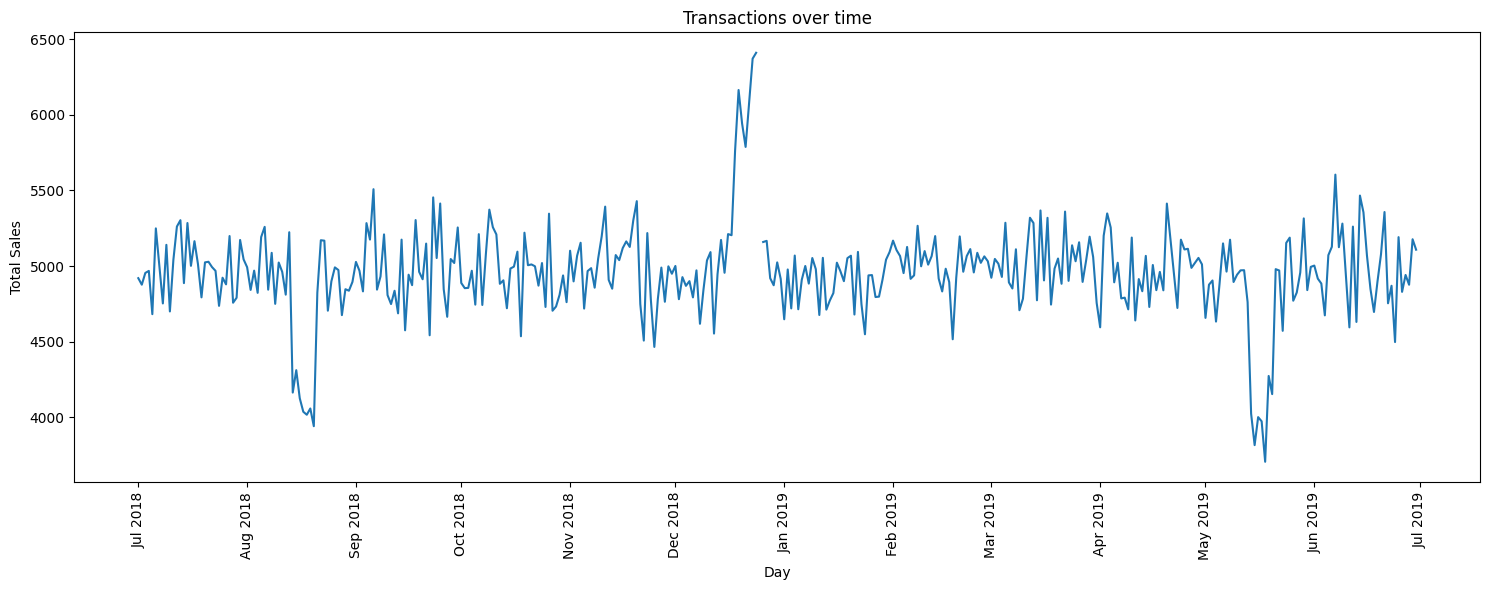

In [18]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(15, 6))

plt.plot(
    transactions_by_day['DATE'],
    transactions_by_day['TOT_SALES'],
    linewidth=1.5
)

plt.title("Transactions over time")
plt.xlabel("Day")
plt.ylabel("Total Sales")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

Here we can see there is a gap in Dec and also maximum sales in a day are in dec too. Let's inspect that

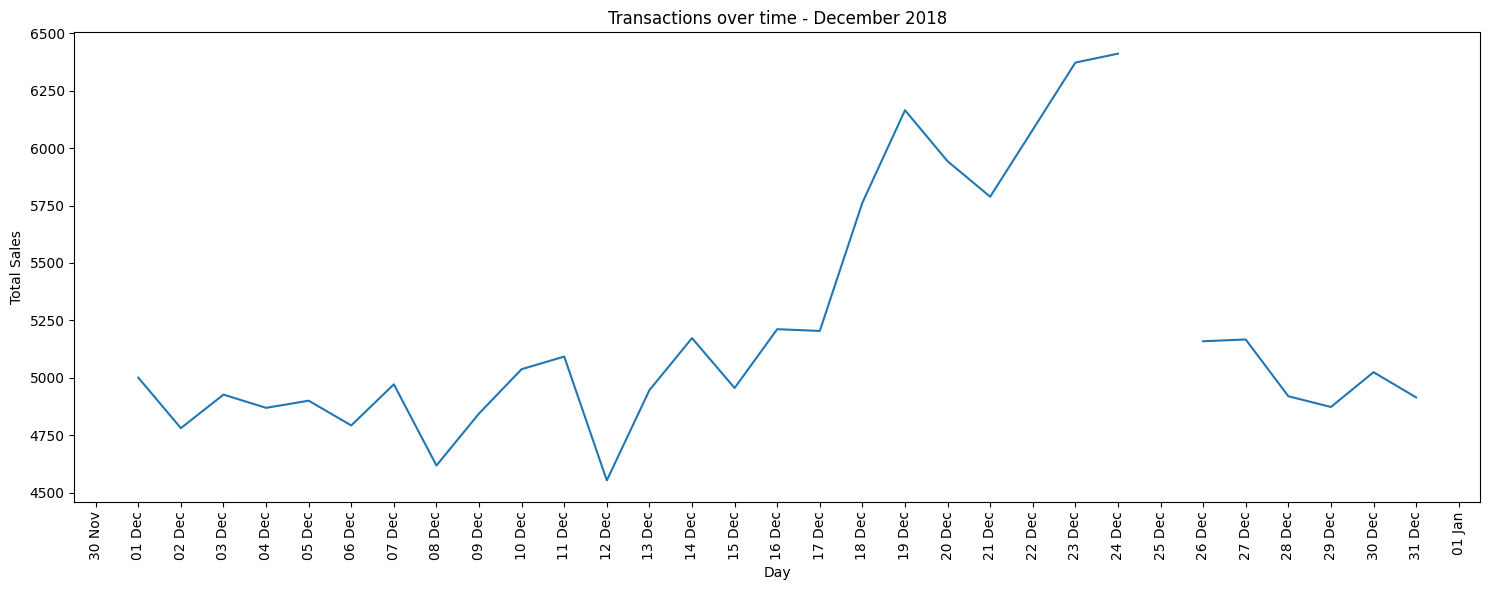

In [19]:
december_data = transactions_by_day[
    (transactions_by_day['DATE'] >= '2018-12-01') &
    (transactions_by_day['DATE'] <= '2018-12-31')
]

plt.figure(figsize=(15, 6))

plt.plot(
    december_data['DATE'],
    december_data['TOT_SALES'],
    linewidth=1.5
)

plt.title("Transactions over time - December 2018")
plt.xlabel("Day")
plt.ylabel("Total Sales")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

You can see Dec 24 has highest no of total sales and dec 23 followed by it. This may be because people are buying more just before christmas day.

Here we can see December 25th is the day the sales data is missing. This may be due to christmas. Let's inspect December data.

Now let's create new feature from product description called pack size.

In [21]:
df_1['PACK_SIZE'] = df_1['PROD_NAME'].str.extract(r'(\d+)').astype(float)

In [22]:
df_1.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES,PACK_SIZE
count,246740,246740.000000,2.467400e+05,2.467400e+05,246740.000000,246740.000000,246740.000000,246740.000000
mean,2018-12-30 01:18:58.448569344,135.050361,1.355303e+05,1.351304e+05,56.352213,1.906456,7.316113,175.583521
min,2018-07-01 00:00:00,1.000000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.700000,70.000000
25%,2018-09-30 00:00:00,70.000000,7.001500e+04,6.756875e+04,26.000000,2.000000,5.800000,150.000000
50%,2018-12-30 00:00:00,130.000000,1.303670e+05,1.351815e+05,53.000000,2.000000,7.400000,170.000000
75%,2019-03-31 00:00:00,203.000000,2.030832e+05,2.026522e+05,87.000000,2.000000,8.800000,175.000000
max,2019-06-30 00:00:00,272.000000,2.373711e+06,2.415841e+06,114.000000,5.000000,29.500000,380.000000
std,NaN,76.786971,8.071520e+04,7.814760e+04,33.695235,0.342499,2.474897,59.432118


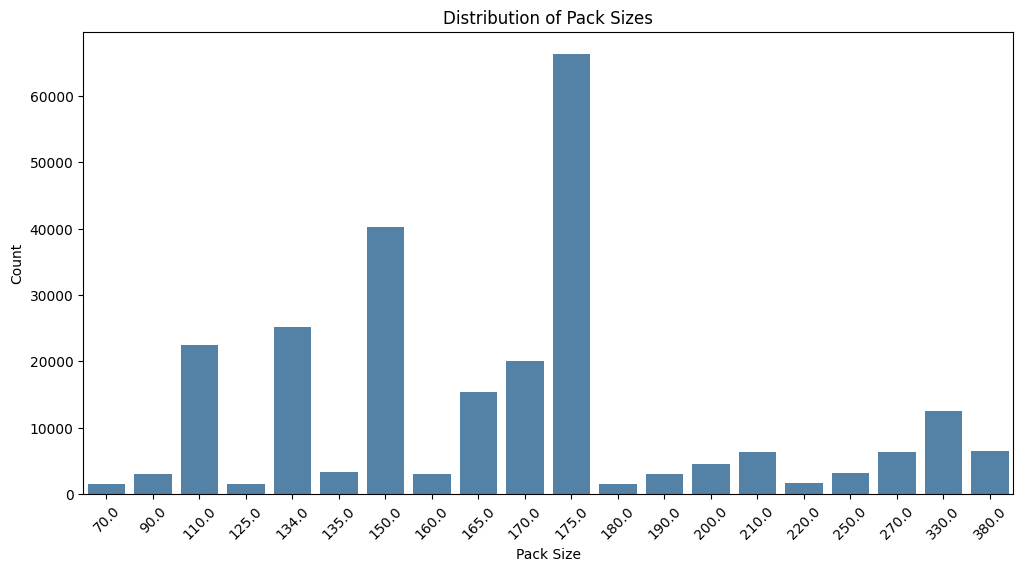

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.countplot(
    data=df_1,
    x='PACK_SIZE',
    order=sorted(df_1['PACK_SIZE'].unique()),
    color='steelblue'
)

plt.xticks(rotation=45)
plt.xlabel('Pack Size')
plt.ylabel('Count')
plt.title('Distribution of Pack Sizes')

plt.show()

Our new feature pack size looks reasonable as the least value is 70g and maax is 380g which is reasonable and most of the chips have size around 175.0g

Now let's create another feature brand name by extracting first word in the product description.

In [31]:
df_1['BRAND'] = df_1['PROD_NAME'].str.split().str[0]

In [32]:
df_1.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175.0,Natural
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175.0,CCs
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170.0,Smiths
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175.0,Smiths
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150.0,Kettle


Now, let's see the distribution of Brands


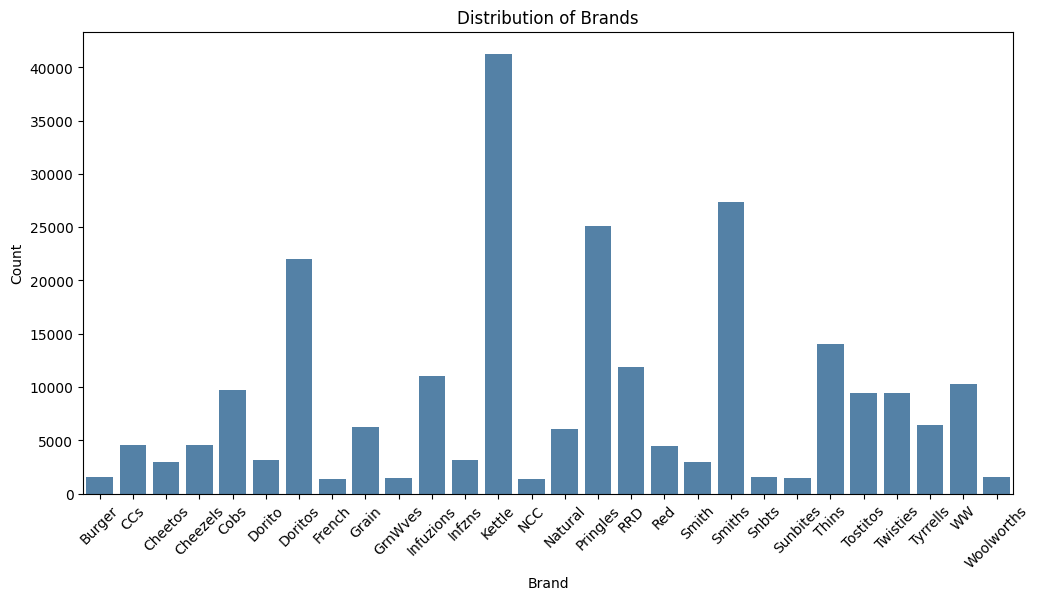

In [33]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df_1,
    x='BRAND',
    order=sorted(df_1['BRAND'].unique()),
    color='steelblue'
)

plt.xticks(rotation=45)
plt.xlabel('Brand')
plt.ylabel('Count')
plt.title('Distribution of Brands')

plt.show()

After inspecting the histogram of brand names, we can see that there are two names for one brand for some brands. So we are gonna replace them as one with same name.

In [34]:
df_1['BRAND'] = df_1['BRAND'].replace('RRD', 'Red')
df_1['BRAND'] = df_1['BRAND'].replace('Smith', 'Smiths')
df_1['BRAND'] = df_1['BRAND'].replace('Snbts', 'Sunbites')
df_1['BRAND'] = df_1['BRAND'].replace('Infzns', 'Infuzions')
df_1['BRAND'] = df_1['BRAND'].replace('WW', 'Woolworths')
df_1['BRAND'] = df_1['BRAND'].replace('NCC', 'Natural')
df_1['BRAND'] = df_1['BRAND'].replace('GrnWves', 'Grain')
df_1['BRAND'] = df_1['BRAND'].replace('Dorito', 'Doritos')

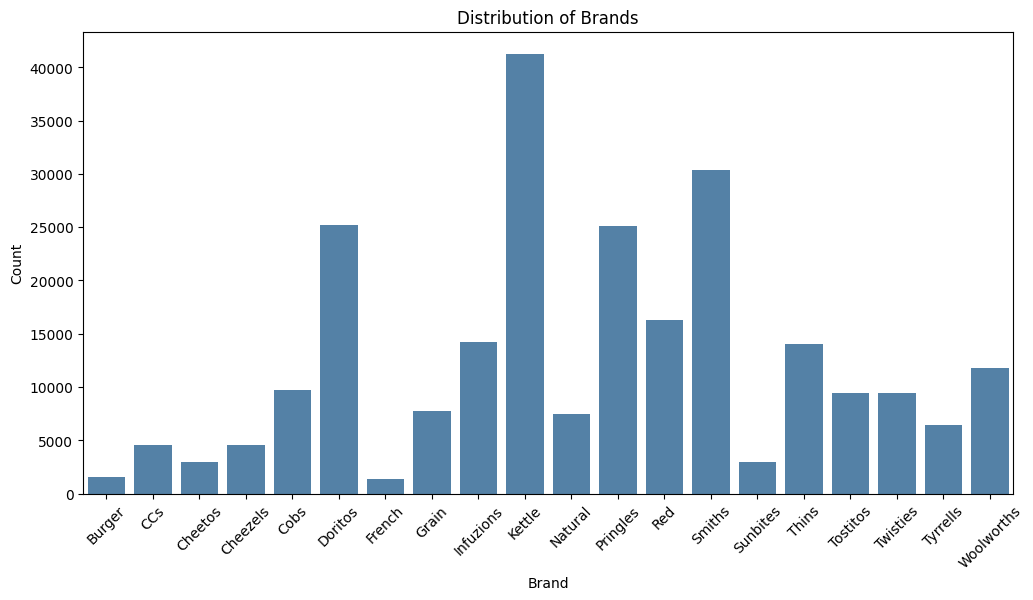

In [35]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df_1,
    x='BRAND',
    order=sorted(df_1['BRAND'].unique()),
    color='steelblue'
)

plt.xticks(rotation=45)
plt.xlabel('Brand')
plt.ylabel('Count')
plt.title('Distribution of Brands')

plt.show()

Now it looks good, there are no duplicate brand names. Every brand is unique now and in total there are 20 brands

As we are happy with the transaction data, now let's inspect customer data

In [36]:
df_2.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [ ]:
df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


There are no null types, so we can conclude that there is no missing data. Let's merge two tables now to get a final merged dataset.

In [37]:
df = df_1.merge(df_2, how = 'left', left_on= 'LYLTY_CARD_NBR', right_on= 'LYLTY_CARD_NBR')

In [38]:
df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175.0,Natural,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175.0,CCs,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170.0,Smiths,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175.0,Smiths,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150.0,Kettle,MIDAGE SINGLES/COUPLES,Budget


In [39]:
df_1.shape

(246740, 10)

In [40]:
df.shape

(246740, 12)

By the size of merged and purchase datasets we can cocnlude that every transaction is being accounted for customer. There are no mismatched Loyalty Card Numberds.

Let's save the merged dataset for future analytics.

In [41]:
path = "../data/merged_chip_data.csv"
df.to_csv(path, index=False)


Now let's see which segment have how many total sales.

In [42]:
sales = (
    df.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TOT_SALES']
      .sum()
      .unstack(fill_value=0)
)

In [43]:
sales

PREMIUM_CUSTOMER,Budget,Mainstream,Premium
LIFESTAGE,,,
MIDAGE SINGLES/COUPLES,33345.70,84734.25,54443.85
NEW FAMILIES,20607.45,15979.70,10760.80
OLDER FAMILIES,156863.75,96413.55,75242.60
OLDER SINGLES/COUPLES,127833.60,124648.50,123537.55
RETIREES,105916.30,145168.95,91296.65
YOUNG FAMILIES,129717.95,86338.25,78571.70
YOUNG SINGLES/COUPLES,57122.10,147582.20,39052.30


Let's see the proportions of which segment have more number of sales.

In [49]:
sales_pct = sales / sales.to_numpy().sum() * 100

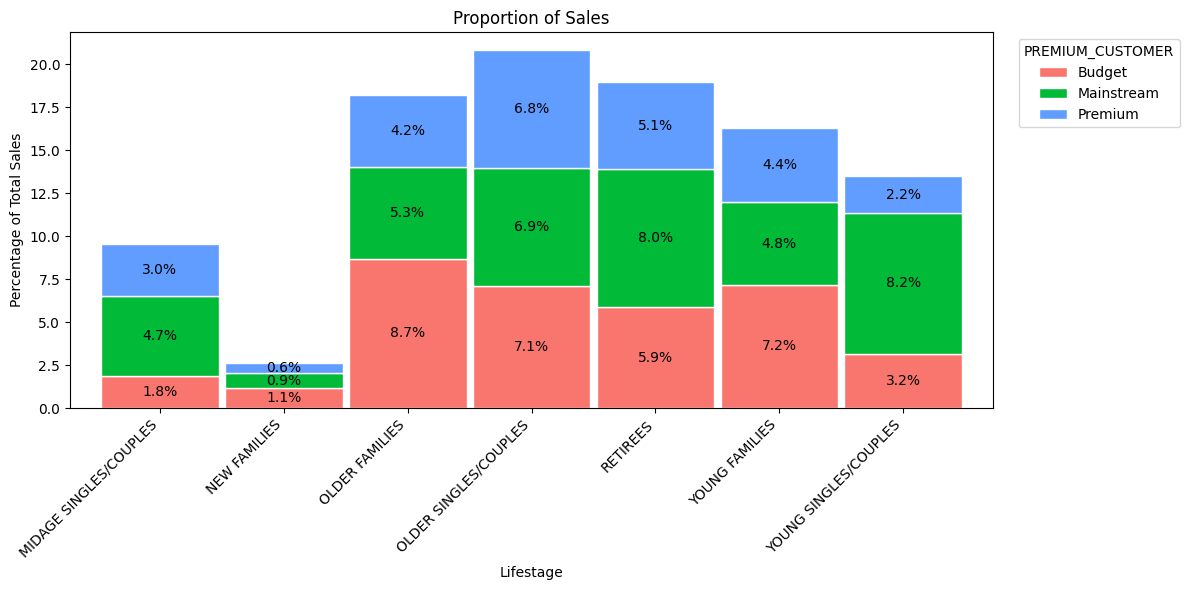

In [48]:
ax = sales_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6),
    color=['#F8766D', '#00BA38', '#619CFF'],
    edgecolor='white',
    width=0.95
)

# Add percentage labels
for container in ax.containers:
    labels = [f'{v:.1f}%' if v >= 0.5 else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=10)

plt.title('Proportion of Sales')
plt.xlabel('Lifestage')
plt.ylabel('Percentage of Total Sales')
plt.xticks(rotation=45, ha='right')
plt.legend(title='PREMIUM_CUSTOMER', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

From this we can see that sales are coming mainly from Budget - older families, Mainstream - young singles/couples, and Mainstream - retirees

Let’s see if the higher sales are due to there being more customers who buy chips.

In [58]:
no_of_customers = (
    df.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['LYLTY_CARD_NBR']
      .nunique()
      .unstack(fill_value=0)
)

In [59]:
no_of_customers

PREMIUM_CUSTOMER,Budget,Mainstream,Premium
LIFESTAGE,,,
MIDAGE SINGLES/COUPLES,1474,3298,2369
NEW FAMILIES,1087,830,575
OLDER FAMILIES,4611,2788,2231
OLDER SINGLES/COUPLES,4849,4858,4682
RETIREES,4385,6358,3812
YOUNG FAMILIES,3953,2685,2398
YOUNG SINGLES/COUPLES,3647,7917,2480


In [60]:
no_of_customers_pct = no_of_customers / no_of_customers.to_numpy().sum() * 100

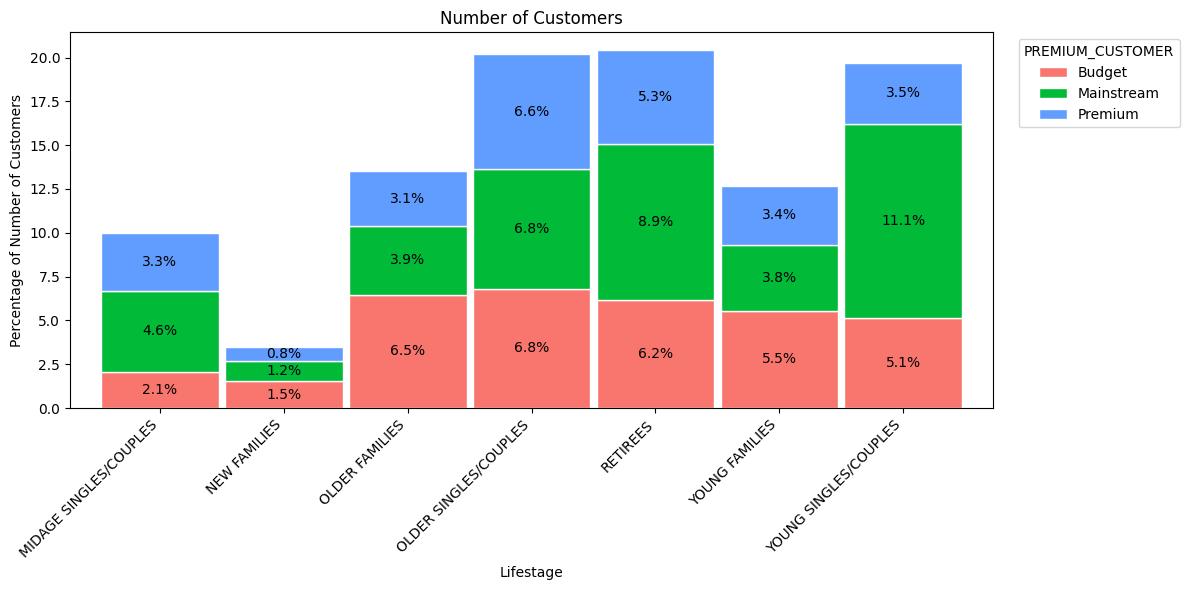

In [61]:
ax = no_of_customers_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6),
    color=['#F8766D', '#00BA38', '#619CFF'],
    edgecolor='white',
    width=0.95
)

# Add percentage labels
for container in ax.containers:
    labels = [f'{v:.1f}%' if v >= 0.5 else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=10)

plt.title('Number of Customers')
plt.xlabel('Lifestage')
plt.ylabel('Percentage of Number of Customers')
plt.xticks(rotation=45, ha='right')
plt.legend(title='PREMIUM_CUSTOMER', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

There are more Mainstream - young singles/couples and Mainstream - retirees who buy chips. This contributes to more sales in these customer segments, but it is not a major driver for the Budget - Older families segment.

Higher sales may also be driven by more units of chips being bought per customer. Let’s have a look at this
next.

In [62]:
avg_units = (
    df.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])
      .agg(
          TOTAL_UNITS=('PROD_QTY', 'sum'),
          CUSTOMERS=('LYLTY_CARD_NBR', 'nunique')
      )
      .reset_index()
)

avg_units['AVG'] = avg_units['TOTAL_UNITS'] / avg_units['CUSTOMERS']

# Sort from highest to lowest average
avg_units = avg_units.sort_values('AVG', ascending=False)

avg_units.head()

,LIFESTAGE,PREMIUM_CUSTOMER,TOTAL_UNITS,CUSTOMERS,AVG
7,OLDER FAMILIES,Mainstream,25804,2788,9.255380
6,OLDER FAMILIES,Budget,41853,4611,9.076773
8,OLDER FAMILIES,Premium,20239,2231,9.071717
15,YOUNG FAMILIES,Budget,34482,3953,8.722995
17,YOUNG FAMILIES,Premium,20901,2398,8.716013


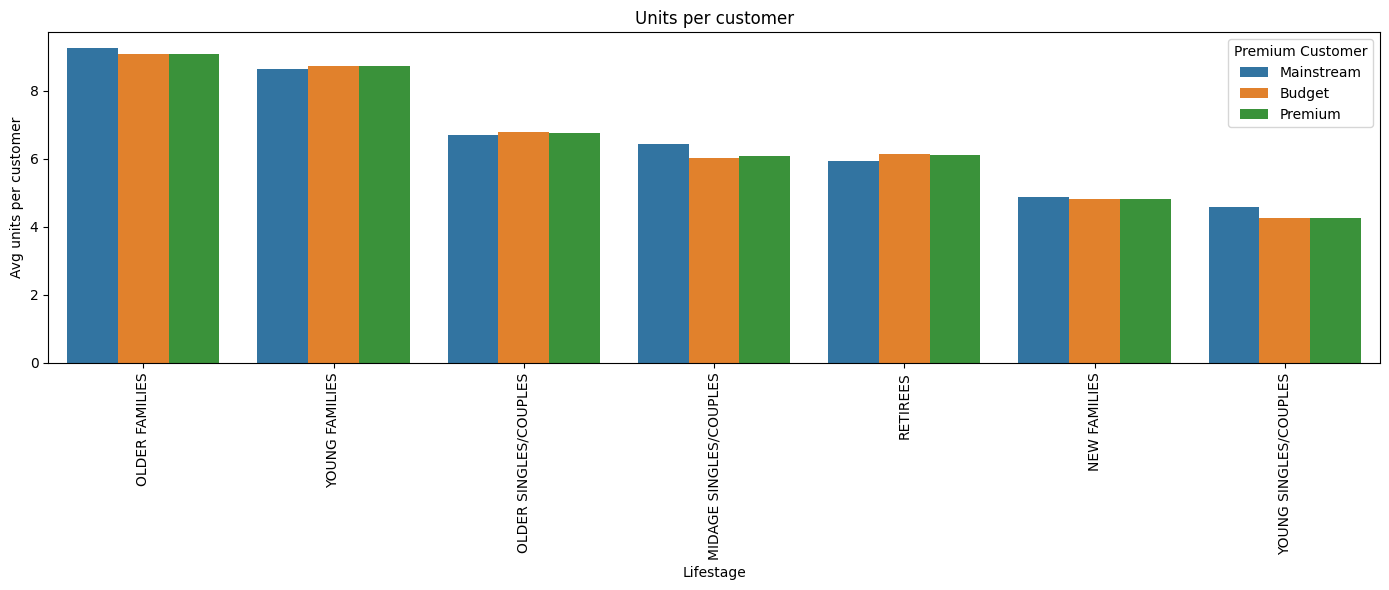

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))

sns.barplot(
    data=avg_units,
    x='LIFESTAGE',
    y='AVG',
    hue='PREMIUM_CUSTOMER'
)

plt.title('Units per customer')
plt.xlabel('Lifestage')
plt.ylabel('Avg units per customer')

plt.xticks(rotation=90)

plt.legend(title='Premium Customer')
plt.tight_layout()
plt.show()

Older families and young families in general buy more chips per customer

Let’s also investigate the average price per unit chips bought for each customer segment as this is also a
driver of total sales.

In [68]:
avg_price = (
    df.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])
      .agg(
          TOTAL_UNITS=('PROD_QTY', 'sum'),
          TOTAL_SALES=('TOT_SALES', 'sum')
      )
      .reset_index()
)

avg_price['AVG'] = avg_price['TOTAL_SALES'] / avg_price['TOTAL_UNITS']

# Sort from highest to lowest average
avg_price = avg_price.sort_values('AVG', ascending=False)

avg_price.head()

,LIFESTAGE,PREMIUM_CUSTOMER,TOTAL_UNITS,TOTAL_SALES,AVG
19,YOUNG SINGLES/COUPLES,Mainstream,36225,147582.20,4.074043
1,MIDAGE SINGLES/COUPLES,Mainstream,21213,84734.25,3.994449
4,NEW FAMILIES,Mainstream,4060,15979.70,3.935887
12,RETIREES,Budget,26932,105916.30,3.932731
3,NEW FAMILIES,Budget,5241,20607.45,3.931969


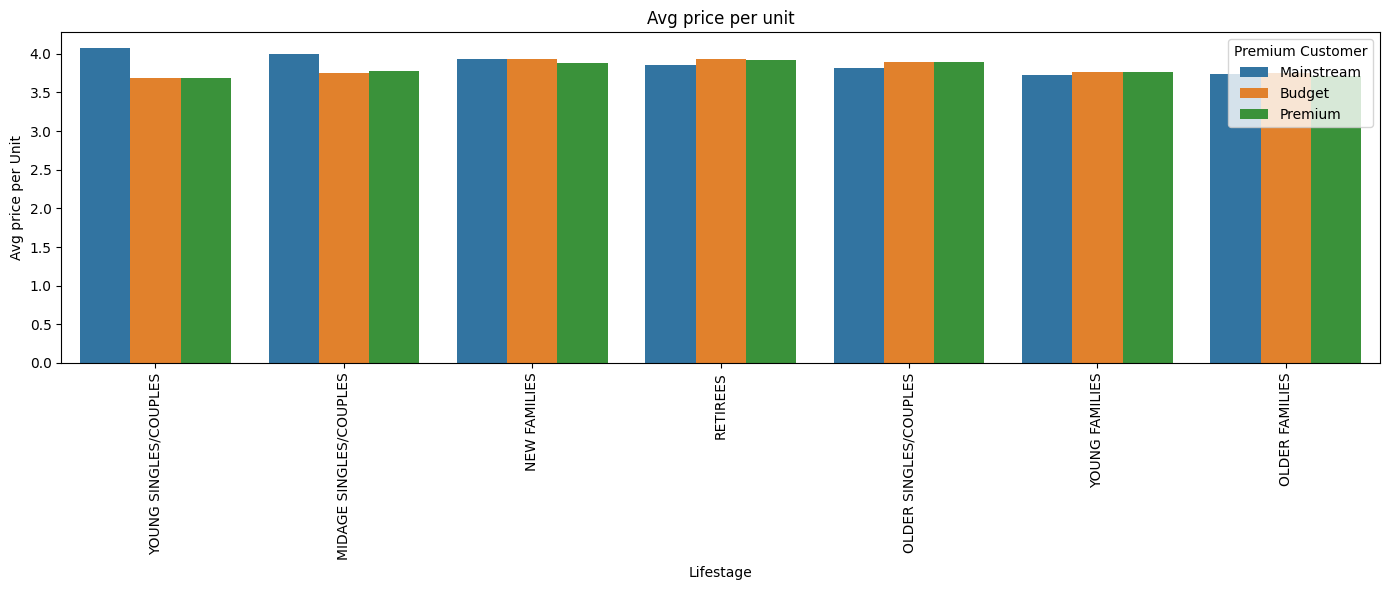

In [71]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=avg_price,
    x='LIFESTAGE',
    y='AVG',
    hue='PREMIUM_CUSTOMER'
)

plt.title('Avg price per unit')
plt.xlabel('Lifestage')
plt.ylabel('Avg price per Unit')

plt.xticks(rotation=90)

plt.legend(title='Premium Customer')
plt.tight_layout()
plt.show()

Mainstream midage and young singles and couples are more willing to pay more per packet of chips compared to their budget and premium counterparts. This may be due to premium shoppers being more likely to buy healthy snacks and when they buy chips, this is mainly for entertainment purposes rather than their own consumption. This is also supported by there being fewer premium midage and young singles and couples buying chips compared to their mainstream counterparts.

As the difference in average price per unit isn’t large, we can check if this difference is statistically different.

In [70]:
import pandas as pd
from scipy.stats import ttest_ind

# Price per unit for each transaction
df['PRICE_PER_UNIT'] = df['TOT_SALES'] / df['PROD_QTY']

# Mainstream group
mainstream = df[
    (df['LIFESTAGE'].isin(['YOUNG SINGLES/COUPLES',
                           'MIDAGE SINGLES/COUPLES'])) &
    (df['PREMIUM_CUSTOMER'] == 'Mainstream')
]['PRICE_PER_UNIT']

# Budget + Premium group
others = df[
    (df['LIFESTAGE'].isin(['YOUNG SINGLES/COUPLES',
                           'MIDAGE SINGLES/COUPLES'])) &
    (df['PREMIUM_CUSTOMER'] != 'Mainstream')
]['PRICE_PER_UNIT']

# Independent t-test (Welch's t-test)
t_stat, p_two_sided = ttest_ind(
    mainstream,
    others,
    equal_var=False
)

# Convert to one-sided p-value (Mainstream > Others)
if t_stat > 0:
    p_one_sided = p_two_sided / 2
else:
    p_one_sided = 1 - p_two_sided / 2

print(f"T-statistic : {t_stat:.4f}")
print(f"One-sided p-value: {p_one_sided:.2e}")

T-statistic : 37.6244
One-sided p-value: 3.48e-306


The t-test results in a p-value = 3.48e-306, i.e. the unit price for mainstream, young and mid-age singles and
couples are significantly higher than that of budget or premium, young and midage singles and couples.

We have found quite a few interesting insights that we can dive deeper into.
We might want to target customer segments that contribute the most to sales to retain them or further
increase sales. Let’s look at Mainstream - young singles/couples. For instance, let’s find out if they tend to
buy a particular brand of chips.

In [72]:
mainstream_young = df.loc[(df['PREMIUM_CUSTOMER'] == 'Mainstream') & (df['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES')]

In [81]:
other = df.loc[~((df['PREMIUM_CUSTOMER'] == 'Mainstream') & (df['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES'))]

In [83]:
# Total quantity purchased by each group
quantity_segment1 = mainstream_young['PROD_QTY'].sum()
quantity_other = other['PROD_QTY'].sum()

# Proportion of quantity purchased by brand within each group
quantity_segment1_by_brand = (
    mainstream_young.groupby('BRAND', as_index=False)['PROD_QTY']
    .sum()
)

quantity_segment1_by_brand['targetSegment'] = (
    quantity_segment1_by_brand['PROD_QTY'] / quantity_segment1
)

quantity_other_by_brand = (
    other.groupby('BRAND', as_index=False)['PROD_QTY']
    .sum()
)

quantity_other_by_brand['other'] = (
    quantity_other_by_brand['PROD_QTY'] / quantity_other
)

# Merge the two tables
brand_proportions = (
    quantity_segment1_by_brand[['BRAND', 'targetSegment']]
    .merge(
        quantity_other_by_brand[['BRAND', 'other']],
        on='BRAND'
    )
)

# Calculate brand affinity
brand_proportions['affinityToBrand'] = (
    brand_proportions['targetSegment'] /
    brand_proportions['other']
)

# Sort from highest affinity to lowest
brand_proportions = brand_proportions.sort_values(
    'affinityToBrand',
    ascending=False
)

brand_proportions

,BRAND,targetSegment,other,affinityToBrand
18,Tyrrells,0.031553,0.025692,1.228095
17,Twisties,0.046184,0.037877,1.219319
5,Doritos,0.122761,0.101075,1.214553
9,Kettle,0.197985,0.165553,1.195897
16,Tostitos,0.045411,0.037978,1.195713
11,Pringles,0.119420,0.100635,1.186670
4,Cobs,0.044638,0.039049,1.143124
8,Infuzions,0.064679,0.057065,1.133435
15,Thins,0.060373,0.056986,1.059423
7,Grain,0.032712,0.031188,1.048873


We can see that :

*   Mainstream young singles/couples are 23% more likely to purchase Tyrrells chips compared to the rest of the population
*   Mainstream young singles/couples are 56% less likely to purchase Burger Rings compared to the rest of the population



In [84]:
# Proportion of quantity purchased by brand within each group
quantity_segment1_by_pack = (
    mainstream_young.groupby('PACK_SIZE', as_index=False)['PROD_QTY']
    .sum()
)

quantity_segment1_by_pack['targetSegment'] = (
    quantity_segment1_by_pack['PROD_QTY'] / quantity_segment1
)

quantity_other_by_pack = (
    other.groupby('PACK_SIZE', as_index=False)['PROD_QTY']
    .sum()
)

quantity_other_by_pack['other'] = (
    quantity_other_by_pack['PROD_QTY'] / quantity_other
)

# Merge the two tables
pack_proportions = (
    quantity_segment1_by_pack[['PACK_SIZE', 'targetSegment']]
    .merge(
        quantity_other_by_pack[['PACK_SIZE', 'other']],
        on='PACK_SIZE'
    )
)

# Calculate brand affinity
pack_proportions['affinityToPack'] = (
    pack_proportions['targetSegment'] /
    pack_proportions['other']
)

# Sort from highest affinity to lowest
pack_proportions = pack_proportions.sort_values(
    'affinityToPack',
    ascending=False
)

pack_proportions

,PACK_SIZE,targetSegment,other,affinityToPack
17,270.0,0.031829,0.025096,1.268287
19,380.0,0.032160,0.025584,1.257030
18,330.0,0.061284,0.050162,1.221717
4,134.0,0.119420,0.100635,1.186670
2,110.0,0.106280,0.089791,1.183637
14,210.0,0.029124,0.025121,1.159318
5,135.0,0.014769,0.013075,1.129511
16,250.0,0.014355,0.012781,1.123166
9,170.0,0.080773,0.080986,0.997370
6,150.0,0.157598,0.163421,0.964372


It looks like Mainstream young singles/couples are 27% more likely to purchase a 270g pack of chips compared to the rest of the population but let’s dive into what brands sell this pack size.

In [85]:
df_270 = df.loc[df['PACK_SIZE'] == 270]['BRAND'].value_counts().reset_index()
df_270.columns = ['BRAND', 'count']
df_270

,BRAND,count
0,Twisties,6285


Twisties are the only brand offering 270g packs and so this may instead be reflecting a higher likelihood of
purchasing Twisties.

### **CONCLUSIONS:**

*   Sales have mainly been due to Budget - older families, Mainstream - young singles/couples, and Mainstream - retirees shoppers. We found that the high spend in chips for mainstream young singles/couples and retirees is due to there being more of them than other buyers. Mainstream, midage and young singles and couples are also more likely to pay more per packet of chips. This is indicative of impulse buying behaviour.

*   We’ve also found that Mainstream young singles and couples are 23% more likely to purchase Tyrrells chips compared to the rest of the population.

*   The Category Manager may want to increase the category’s performance by off-locating some Tyrrells and smaller packs of chips in discretionary space near segments where young singles and couples frequent more often to increase visibilty and impulse behaviour.




